# Baidu's RT-DETR: A Vision Transformer-Based Real-Time Object Detector

### Overview

Real-Time Detection Transformer (RT-DETR), developed by Baidu, is a cutting-edge end-to-end object detector that provides real-time performance while maintaining high accuracy. It is based on the idea of DETR (the NMS-free framework), meanwhile introducing conv-based backbone and an efficient hybrid encoder to gain real-time speed. RT-DETR efficiently processes multiscale features by decoupling intra-scale interaction and cross-scale fusion. The model is highly adaptable, supporting flexible adjustment of inference speed using different decoder layers without retraining. RT-DETR excels on accelerated backends like CUDA with TensorRT, outperforming many other real-time object detectors.

<img src="https://github.com/ultralytics/docs/releases/download/0/baidu-rtdetr-model-overview.avif" width="50%" height="50%" alt="YOLOv10">

----

Conda env : [cv_playgrounds](../README.md#setup-a-conda-environment)

----

- Ref: 
    - https://docs.ultralytics.com/models/rtdetr/#overview

### Overview of Baidu's RT-DETR. 
The RT-DETR model architecture diagram shows the last three stages of the backbone {S3, S4, S5} as the input to the encoder. The efficient hybrid encoder transforms multiscale features into a sequence of image features through intrascale feature interaction (AIFI) and cross-scale feature-fusion module (CCFM). The IoU-aware query selection is employed to select a fixed number of image features to serve as initial object queries for the decoder. Finally, the decoder with auxiliary prediction heads iteratively optimizes object queries to generate boxes and confidence scores (source).

### Key Features
- **Efficient Hybrid Encoder**: Baidu's RT-DETR uses an efficient hybrid encoder that processes multiscale features by decoupling intra-scale interaction and cross-scale fusion. This unique Vision Transformers-based design reduces computational costs and allows for real-time object detection.

- **IoU-aware Query Selection**: Baidu's RT-DETR improves object query initialization by utilizing IoU-aware query selection. This allows the model to focus on the most relevant objects in the scene, enhancing the detection accuracy.

- **Adaptable Inference Speed**: Baidu's RT-DETR supports flexible adjustments of inference speed by using different decoder layers without the need for retraining. This adaptability facilitates practical application in various real-time object detection scenarios.

- **NMS-Free Framework**: Based on DETR, RT-DETR eliminates the need for non-maximum suppression post-processing, simplifying the detection pipeline and potentially improving efficiency.

- **Anchor-Free Detection**: As an anchor-free detector, RT-DETR simplifies the detection process and may improve generalization across different datasets.

In [5]:
!nvidia-smi

Fri Nov 21 21:16:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     On  |   00000000:01:00.0  On |                  N/A |
| 32%   48C    P5             36W /  250W |    8712MiB /  11264MiB |     27%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Download test data

In [4]:
from ultralytics.utils.downloads import safe_download
images = ["bus.jpg", "zidane.jpg"]
for img in images:
  path = safe_download(f"https://ultralytics.com/assets/{img}", dir="temp_assets")

### Mobile-SAM :: Point prompt

rt-detr-l summary: 449 layers, 32,970,476 parameters, 0 gradients, 108.3 GFLOPs

image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x640 4 persons, 1 bus, 1 traffic light, 1 fire hydrant, 2 ties, 40.6ms
Speed: 6.1ms preprocess, 40.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


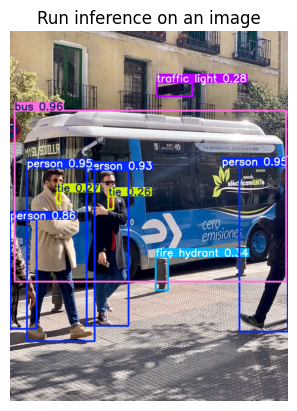

In [ ]:
from ultralytics import RTDETR
import matplotlib.pyplot as plt
import cv2


# Define an inference source
source = "./temp_assets/bus.jpg"

# Load a COCO-pretrained RT-DETR-l model
model = RTDETR("./temp_model/rtdetr-l.pt")

# Display model information (optional)
model.info()

# Run inference with the RT-DETR-l model on the 'bus.jpg' image
results = model(source)
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()




In [3]:
# Train the model on the COCO8 example dataset for 100 epochs
results = model.train(data="coco8.yaml", epochs=100, imgsz=640)


Ultralytics 8.3.230 🚀 Python-3.10.12 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10815MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=./temp_model/rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

/home/hyunjae/anaconda3/envs/cv_playgrounds/lib/python3.10/site-packages/torch/autograd/graph.py:829: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.9it/s 0.3s
                   all          4         17          0          0          0          0

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/100      3.62G       1.47     0.7746      1.049         39        640: 100% ━━━━━━━━━━━━ 1/1 1.8it/s 0.5s


/home/hyunjae/anaconda3/envs/cv_playgrounds/lib/python3.10/site-packages/torch/autograd/graph.py:829: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 5.6it/s 0.2s
                   all          4         17          0          0          0          0

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      3/100      3.65G      1.363      1.397       1.36          8        640: 100% ━━━━━━━━━━━━ 1/1 2.1it/s 0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 17.8it/s 0.1s
                   all          4         17          0          0          0          0


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.6it/s 0.2s
                   all          4         17          0          0          0          0

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     99/100      4.61G     0.7164     0.9379     0.7579         13        640: 100% ━━━━━━━━━━━━ 1/1 2.1it/s 0.5s


/home/hyunjae/anaconda3/envs/cv_playgrounds/lib/python3.10/site-packages/torch/autograd/graph.py:829: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.5it/s 0.2s
                   all          4         17          0          0          0          0

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
    100/100       4.9G     0.7331      1.108     0.9822         10        640: 100% ━━━━━━━━━━━━ 1/1 1.2it/s 0.9s


/home/hyunjae/anaconda3/envs/cv_playgrounds/lib/python3.10/site-packages/torch/autograd/graph.py:829: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 12.0it/s 0.1s
                   all          4         17          0          0          0          0

100 epochs completed in 0.064 hours.
Optimizer stripped from /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/runs/detect/train/weights/last.pt, 66.5MB
Optimizer stripped from /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/runs/detect/train/weights/best.pt, 66.5MB

Validating /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/runs/detect/train/weights/best.pt...
Ultralytics 8.3.230 🚀 Python-3.10.12 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10815MiB)
rt-detr-l summary: 302 layers, 32,148,140 parameters, 0 gradients, 103.8 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 20.5it/s 0.0s
                   all          4         1


image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/bus.jpg: 640x640 4 persons, 1 bus, 1 traffic light, 1 fire hydrant, 2 ties, 115.4ms
Speed: 28.3ms preprocess, 115.4ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)


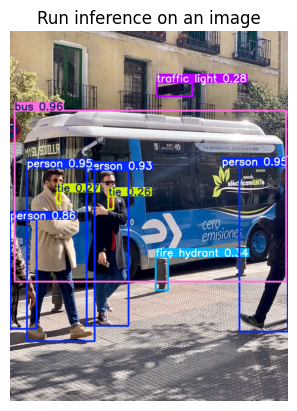

In [4]:
# Run inference with the RT-DETR-l model on the 'bus.jpg' image
results = model("./temp_assets/bus.jpg")
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()


image 1/1 /home/hyunjae/110_HyunJae_Git/2025_Playgrounds/CV_Playgrounds/2DCV/Yolo/temp_assets/zidane.jpg: 640x640 2 persons, 2 ties, 106.9ms
Speed: 21.6ms preprocess, 106.9ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)


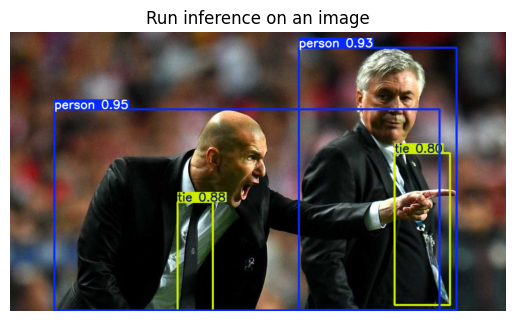

In [5]:
# Run inference with the RT-DETR-l model on the 'bus.jpg' image
results = model("./temp_assets/zidane.jpg")
bgr_image = results[0].plot()
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis('off')
plt.title("Run inference on an image")
plt.show()